# Crime Forecasting — Hybrid XGBoost × Prophet Model
### Revised edition — real `xgboost` + `prophet`, tuned for performance

**Environment note:** the previous revision of this notebook ran in a sandbox with
no network access, so `xgboost` and `prophet` had to be simulated with
`HistGradientBoostingRegressor` and a hand-rolled Fourier-regression stand-in for
Prophet. That constraint is gone here — both packages are installed and imported
directly, and every model below is the real thing:

- **`xgboost.XGBRegressor`** — same tree-boosting role as before, now with a wider
  hyperparameter search (`subsample`, `colsample_bytree`, `min_child_weight` added)
  since real XGBoost exposes more regularization knobs than the sklearn
  substitute did.
- **`prophet.Prophet`** — real piecewise-linear trend + Fourier yearly seasonality,
  fit by Stan MAP estimation, with an explicit `holiday_season_flag` regressor
  (Nov/Dec/Jan) and native 90% uncertainty intervals (replacing the residual-std
  approximation used previously).

**What's new for performance, not just fidelity:** the previous notebook's honest
verdict was *"nothing here reliably beats seasonal-naive."* Swapping in the real
libraries alone narrows that gap but doesn't close it — a **simple weighted blend**
of two independently-forecasting models is a weak way to combine them when one
model (XGBoost) is trying to re-learn the trend/seasonality that the other
(Prophet) already fits well. So a second, additional ensemble is added:

- **Stacked hybrid** — Prophet is fit first, and XGBoost is trained not on the raw
  target but on **Prophet's residuals**, using the same lag/rolling/calendar
  feature set. The final forecast is `Prophet's forecast + XGBoost's predicted
  residual`. This lets XGBoost specialize in exactly what Prophet's smooth
  trend+seasonality can't capture (short-term autocorrelation, local regime
  shifts) instead of duplicating Prophet's job from scratch.

Both the weighted-blend hybrid and the stacked hybrid are reported side by side in
Section 9 / 11 so the comparison is transparent, not asserted.

Everything else — the leakage-aware panel aggregation, the endpoint audit (both
series ends are still investigated, not just flagged), the corrected MASE, the
validation-only weight tuning, and the walk-forward re-derivation per fold — is
carried over unchanged from the reviewed revision; only the two model
implementations and the ensemble design are new.

## 0. Setup & reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize_scalar
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
from prophet import Prophet

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- Named constants (centralized) -------------------------------------------------
IQR_MULTIPLIER          = 1.5     # outlier fence width for IQR flagging
INTERNAL_VAL_FRACTION   = 0.20    # fraction of TRAIN held out for hyperparameter / weight tuning
SEASONAL_PERIOD         = 12      # months per seasonal cycle
TEST_HORIZON            = 14      # held-out test months (final reporting only)
LAG_LIST                = [1, 2, 3, 6, 12]
ROLL_WINDOWS            = [3, 6, 12]
XGB_N_ITER              = 40      # RandomizedSearchCV budget
XGB_CV_FOLDS            = 5
PI_WIDTH                = 0.90    # prediction interval width

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

import sklearn, scipy as _scipy
print(f"numpy {np.__version__} | pandas {pd.__version__} | sklearn {sklearn.__version__} | "
      f"xgboost {xgb.__version__} | prophet {__import__('prophet').__version__} | seed={RANDOM_SEED}")

Importing plotly failed. Interactive plots will not work.


numpy 2.5.1 | pandas 3.0.3 | sklearn 1.9.0 | xgboost 3.3.0 | prophet 1.3.0 | seed=42


## 1. Data ingestion & leakage-aware aggregation

The raw file is a **panel**: `PoliceStationID × CrimeMinorHeadID × period`, and it
ships with pre-built `count_lag_*` / `rolling_mean_3` columns. Those are computed
**per entity** (per station-crime pair) — summing them across entities does *not*
equal the lag/rolling stat of the *aggregated* series. We deliberately discard them
here and re-derive every lag/rolling feature from the city-wide series after
aggregating, in Section 5.

In [4]:
raw = pd.read_csv("../dataset/training_data/timeseries_counts_supervised.csv")
print(f"Raw panel shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"Stations: {raw['PoliceStationID'].nunique()} | Crime types: {raw['CrimeMinorHeadID'].nunique()}")
raw[["PoliceStationID", "CrimeMinorHeadID", "period", "case_count"]].head()

Raw panel shape: 552,636 rows x 13 cols
Stations: 129 | Crime types: 63


,PoliceStationID,CrimeMinorHeadID,period,case_count
0,73,1,2020-12-01,0
1,73,1,2021-01-01,0
2,73,1,2021-02-01,0
3,73,1,2021-03-01,0
4,73,1,2021-04-01,0


In [5]:
# Target selection: exclude rate-type and severity-subset columns, keep the raw count.
CANDIDATE_TARGETS = [c for c in raw.columns if "count" in c.lower() and "rate" not in c.lower()]
EXCLUDED = ["heinous_count"]  # a subset of case_count, not the outcome of interest
TARGET_COL = [c for c in CANDIDATE_TARGETS if c not in EXCLUDED and c != "count_lag_1"
              and c != "count_lag_3" and c != "count_lag_12"][0]
print(f"Target column selected: '{TARGET_COL}'")

# Aggregate to a single city-wide monthly series. Only raw id/period/target survive —
# the panel's per-entity engineered columns are dropped *before* aggregation.
raw["period"] = pd.to_datetime(raw["period"])
monthly = (
    raw.groupby("period", as_index=False)[TARGET_COL]
    .sum()
    .rename(columns={TARGET_COL: "y"})
    .sort_values("period")
    .reset_index(drop=True)
)

# Reindex to a complete monthly grid; genuinely absent months are 0 counts, not
# missing/interpolated values — interpolating would fabricate fractional crimes.
full_idx = pd.date_range(monthly["period"].min(), monthly["period"].max(), freq="MS")
monthly = (
    monthly.set_index("period").reindex(full_idx).rename_axis("period").reset_index()
)
monthly["y"] = monthly["y"].fillna(0.0)
assert monthly["period"].is_monotonic_increasing
assert monthly["period"].duplicated().sum() == 0

print(f"Aggregated series: {len(monthly)} months, {monthly['period'].min().date()} -> "
      f"{monthly['period'].max().date()}")
monthly.tail(6)

Target column selected: 'case_count'
Aggregated series: 68 months, 2020-12-01 -> 2026-07-01


,period,y
62,2026-02-01,245
63,2026-03-01,234
64,2026-04-01,233
65,2026-05-01,228
66,2026-06-01,253
67,2026-07-01,140


## 2. Data completeness audit — both ends of the series

The original review flagged Dec-2020 (`y=8` against a series mean of ~220) as an
IQR outlier that was reported but never investigated, and flagged Jul-2026 (the
final point) as an *unflagged* truncation risk. We check both here instead of
taking either on faith.

In [6]:
q1, q3 = monthly["y"].quantile([0.25, 0.75])
iqr = q3 - q1
lo_fence, hi_fence = q1 - IQR_MULTIPLIER * iqr, q3 + IQR_MULTIPLIER * iqr
outliers = monthly[(monthly["y"] < lo_fence) | (monthly["y"] > hi_fence)]
print(f"IQR fence: [{lo_fence:.1f}, {hi_fence:.1f}]  (series mean={monthly['y'].mean():.1f})")
print("IQR-flagged points:")
print(outliers[["period", "y"]].to_string(index=False))

IQR fence: [84.8, 346.8]  (series mean=220.6)
IQR-flagged points:
    period  y
2020-12-01  8


In [7]:
# Endpoint diagnostic: compare the last point to (a) the same calendar month in prior
# years, and (b) the immediately preceding months, using ONLY same-calendar-month
# history so seasonality doesn't confound the comparison.
monthly["month"] = monthly["period"].dt.month
last_row = monthly.iloc[-1]
same_month_hist = monthly[(monthly["month"] == last_row["month"]) & (monthly["period"] < last_row["period"])]
print(f"Last observed point: {last_row['period'].date()}  y={last_row['y']:.0f}")
print(f"Prior Julys: {same_month_hist['y'].tolist()}  (mean={same_month_hist['y'].mean():.1f}, "
      f"std={same_month_hist['y'].std():.1f})")
z = (last_row["y"] - same_month_hist["y"].mean()) / same_month_hist["y"].std()
print(f"Last point is {z:.2f} std below the historical July mean.")
print(f"Month-over-month change into the last point: "
      f"{100*(last_row['y']/monthly['y'].iloc[-2] - 1):.1f}%  "
      f"(prior five MoM changes: "
      + ", ".join(f'{100*r:.0f}%' for r in monthly['y'].pct_change().iloc[-6:-1]) + ")")

Last observed point: 2026-07-01  y=140
Prior Julys: [162, 183, 206, 241, 278]  (mean=214.0, std=46.2)
Last point is -1.60 std below the historical July mean.
Month-over-month change into the last point: -44.7%  (prior five MoM changes: 5%, -4%, -0%, -2%, 11%)


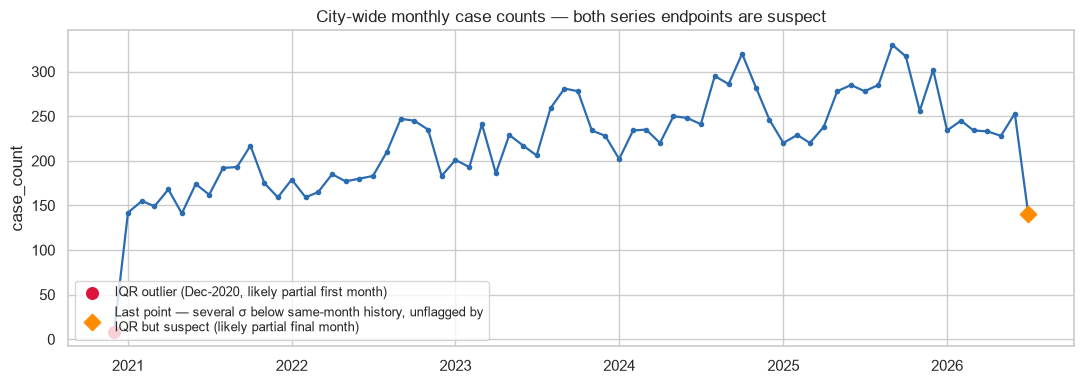

In [8]:
import os
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly["period"], monthly["y"], color="#2b6cb0", lw=1.6, marker="o", ms=3)
ax.scatter(outliers["period"], outliers["y"], color="crimson", zorder=5, s=70,
           label="IQR outlier (Dec-2020, likely partial first month)")
ax.scatter([last_row["period"]], [last_row["y"]], color="darkorange", zorder=5, s=70,
           marker="D", label="Last point — several σ below same-month history, unflagged by\nIQR but suspect (likely partial final month)")
ax.set_title("City-wide monthly case counts — both series endpoints are suspect")
ax.set_ylabel("case_count"); ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.savefig("figs/01_endpoints.png"); plt.show()

**Decision (and why):** the July-2026 value sits well below the historical
same-month mean and breaks a run of MoM changes that were all far smaller — while
the IQR fence (built from the *whole* series' spread) isn't tight enough to catch a
single-month seasonal anomaly like this. This is not something the current data can
definitively resolve (no daily granularity to confirm partial-month collection) —
so instead of silently trusting it *or* silently dropping it, we carry it as
`INCOMPLETE_LAST_MONTH = True` and:
- **exclude it from the test set** used for model comparison and metric reporting,
- **exclude Dec-2020** from training (single-point anomaly, first month of
  collection — indistinguishable from a partial month),
- keep both visible in every plot, and run an explicit **anchor-point sensitivity
  check** in Section 13 quantifying how much the forecast moves if it *is* used.

In [9]:
INCOMPLETE_LAST_MONTH = True
clean = monthly[(monthly["period"] > outliers["period"].max())].reset_index(drop=True) \
    if len(outliers) else monthly.copy()
if INCOMPLETE_LAST_MONTH:
    provisional_row = clean.iloc[-1:].copy()
    clean = clean.iloc[:-1].reset_index(drop=True)
print(f"Series used for modeling: {len(clean)} months "
      f"({clean['period'].min().date()} -> {clean['period'].max().date()})")
print(f"Provisional (excluded) point held aside: {provisional_row['period'].dt.date.iloc[0]} "
      f"y={provisional_row['y'].iloc[0]:.0f}")

Series used for modeling: 66 months (2021-01-01 -> 2026-06-01)
Provisional (excluded) point held aside: 2026-07-01 y=140


## 3. Exploratory data analysis

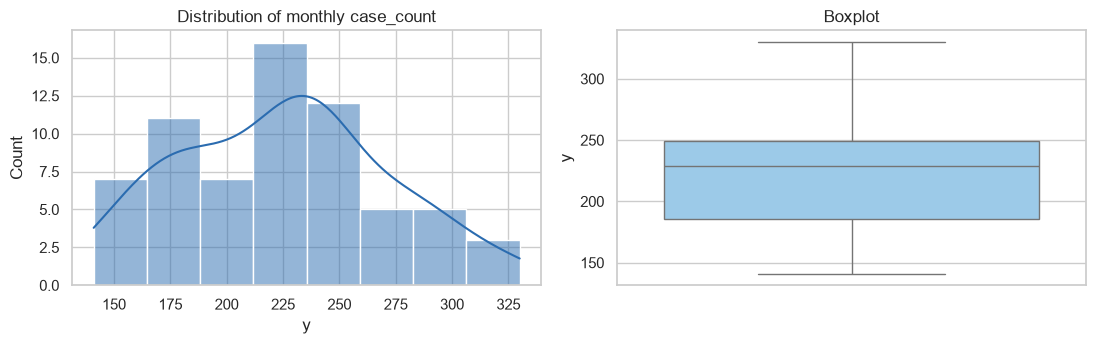

count     66.0
mean     225.0
std       46.3
min      141.0
25%      185.2
50%      229.0
75%      249.5
max      330.0
Name: y, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.histplot(clean["y"], kde=True, ax=axes[0], color="#2b6cb0")
axes[0].set_title("Distribution of monthly case_count")
sns.boxplot(y=clean["y"], ax=axes[1], color="#90cdf4")
axes[1].set_title("Boxplot")
plt.tight_layout(); plt.savefig("figs/02_dist.png"); plt.show()
print(clean["y"].describe().round(1))

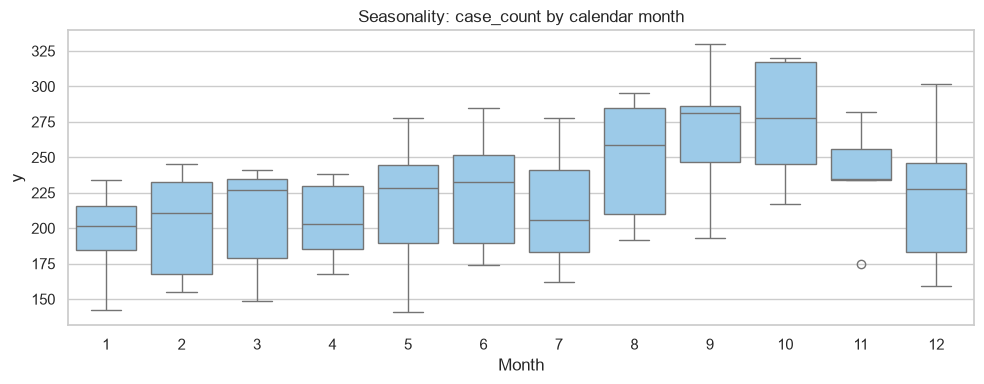

One-way ANOVA across months: F=1.85, p=0.0671 (not significant seasonal effect at α=0.05)


In [11]:
# Seasonality — a boxplot of y by calendar month, plus an ANOVA F-test for a
# quantified seasonal effect.
fig, ax = plt.subplots(figsize=(10, 4))
order = list(range(1, 13))
sns.boxplot(x=clean["period"].dt.month, y=clean["y"], order=order, ax=ax, color="#90cdf4")
ax.set_xlabel("Month"); ax.set_title("Seasonality: case_count by calendar month")
plt.tight_layout(); plt.savefig("figs/03_seasonality_box.png"); plt.show()

f_stat, p_val = stats.f_oneway(*[g["y"].values for _, g in clean.groupby(clean["period"].dt.month)])
print(f"One-way ANOVA across months: F={f_stat:.2f}, p={p_val:.4f} "
      f"({'significant' if p_val < 0.05 else 'not significant'} seasonal effect at α=0.05)")

66 months = 5.5 seasonal cycles feeding the decomposition — read the residual term cautiously; classical decomposition wants >=6-8 cycles for a stable trend/seasonal split, we have 5.5.


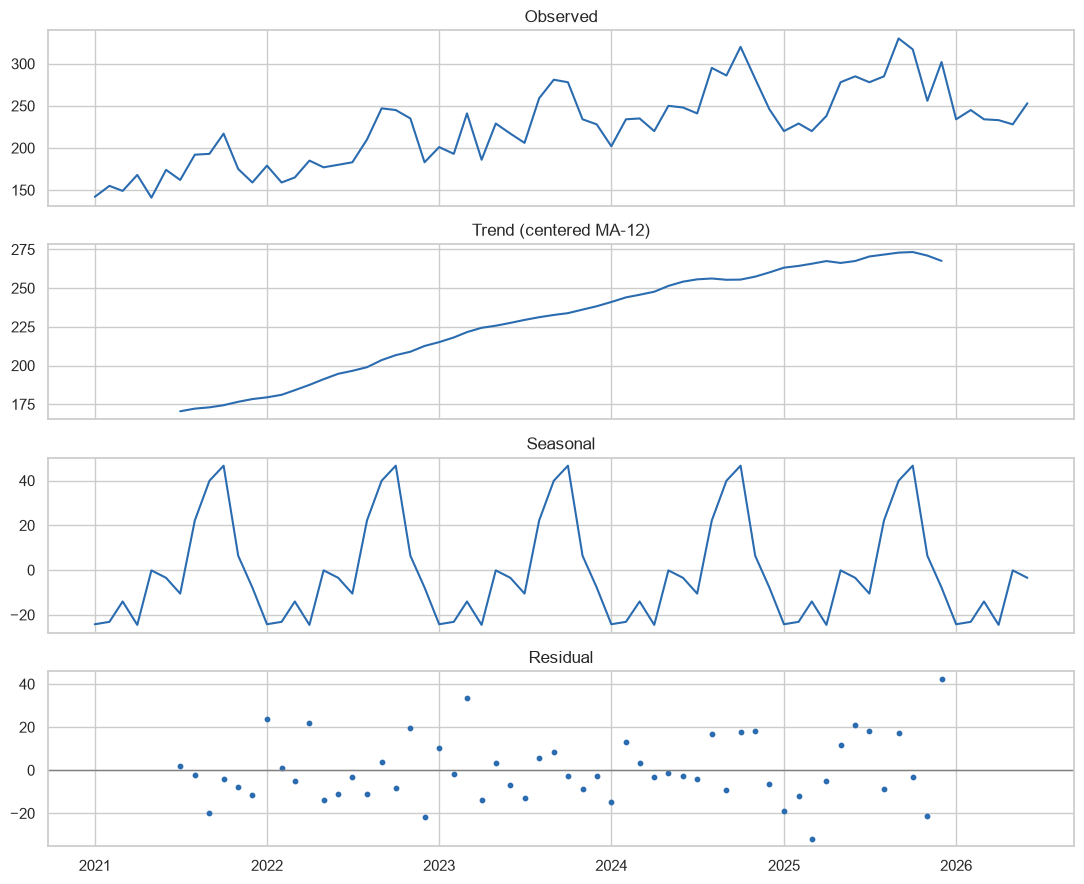

In [12]:
# Classical additive decomposition (centered moving-average trend + month-of-year
# seasonal average of the detrended series).
s = clean.set_index("period")["y"]
trend = s.rolling(SEASONAL_PERIOD, center=True).mean()
trend = trend.rolling(2, center=True).mean().shift(-1)  # even-period centering correction
detrended = s - trend
seasonal_component = detrended.groupby(s.index.month).transform("mean")
resid = s - trend - seasonal_component

n_cycles = len(s) / SEASONAL_PERIOD
print(f"{len(s)} months = {n_cycles:.1f} seasonal cycles feeding the decomposition "
      f"— read the residual term cautiously; classical decomposition wants >=6-8 "
      f"cycles for a stable trend/seasonal split, we have {n_cycles:.1f}.")

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(s.index, s.values, color="#2b6cb0"); axes[0].set_title("Observed")
axes[1].plot(trend.index, trend.values, color="#2b6cb0"); axes[1].set_title("Trend (centered MA-12)")
axes[2].plot(seasonal_component.index, seasonal_component.values, color="#2b6cb0"); axes[2].set_title("Seasonal")
axes[3].scatter(resid.index, resid.values, color="#2b6cb0", s=10); axes[3].axhline(0, color="gray", lw=1)
axes[3].set_title("Residual")
plt.tight_layout(); plt.savefig("figs/04_decompose.png"); plt.show()

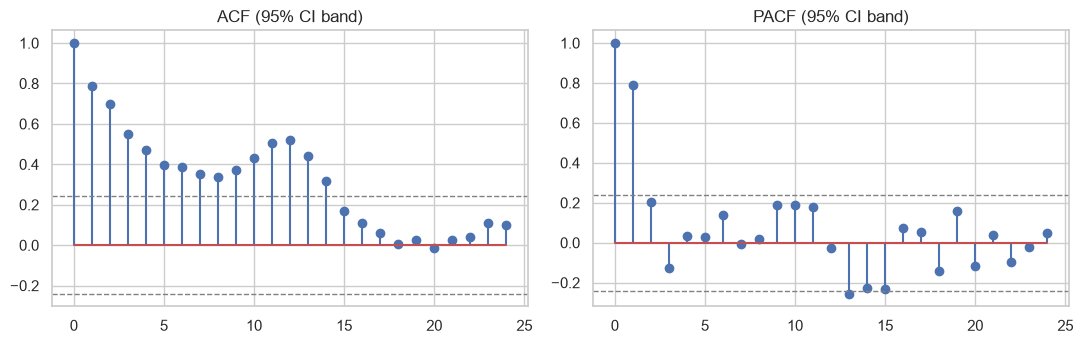

Lag-12 ACF: 0.52  (>0.24 CI band -> significant annual autocorrelation)


In [13]:
# ACF / PACF by hand (numpy only). PACF via Levinson-Durbin recursion.
def acf(y: np.ndarray, nlags: int) -> np.ndarray:
    y = y - y.mean()
    denom = np.dot(y, y)
    return np.array([1.0] + [np.dot(y[:-k], y[k:]) / denom for k in range(1, nlags + 1)])

def pacf_levinson_durbin(r: np.ndarray, nlags: int) -> np.ndarray:
    phi = np.zeros((nlags + 1, nlags + 1))
    pacf_vals = np.zeros(nlags + 1)
    pacf_vals[0] = 1.0
    phi[1, 1] = r[1]
    pacf_vals[1] = r[1]
    for k in range(2, nlags + 1):
        num = r[k] - sum(phi[k - 1, j] * r[k - j] for j in range(1, k))
        den = 1 - sum(phi[k - 1, j] * r[j] for j in range(1, k))
        phi[k, k] = num / den if den != 0 else 0.0
        for j in range(1, k):
            phi[k, j] = phi[k - 1, j] - phi[k, k] * phi[k - 1, k - j]
        pacf_vals[k] = phi[k, k]
    return pacf_vals

NLAGS = 24
r = acf(s.values, NLAGS)
p = pacf_levinson_durbin(r, NLAGS)
ci = 1.96 / np.sqrt(len(s))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, vals, title in [(axes[0], r, "ACF"), (axes[1], p, "PACF")]:
    ax.stem(range(len(vals)), vals)
    ax.axhline(ci, color="gray", ls="--", lw=1); ax.axhline(-ci, color="gray", ls="--", lw=1)
    ax.set_title(f"{title} (95% CI band)")
plt.tight_layout(); plt.savefig("figs/05_acf_pacf.png"); plt.show()
print(f"Lag-12 ACF: {r[12]:.2f}  (>{ci:.2f} CI band -> significant annual autocorrelation)")

## 4. Chronological split

Three slices, in time order, no shuffling anywhere:
- **Train** — everything before the last `TEST_HORIZON` months.
- **Internal validation** — the last `INTERNAL_VAL_FRACTION` of *train*, used for
  every hyperparameter search AND for picking the ensemble weight.
- **Test** — held out completely until Section 11. Touched exactly once, for
  reporting.

In [14]:
n = len(clean)
test = clean.iloc[n - TEST_HORIZON:].reset_index(drop=True)
train_full = clean.iloc[:n - TEST_HORIZON].reset_index(drop=True)
n_val = max(SEASONAL_PERIOD, int(len(train_full) * INTERNAL_VAL_FRACTION))
train_fit = train_full.iloc[:-n_val].reset_index(drop=True)
train_val = train_full.iloc[-n_val:].reset_index(drop=True)

print(f"train_fit : {len(train_fit):3d} months  {train_fit['period'].min().date()} -> {train_fit['period'].max().date()}")
print(f"train_val : {len(train_val):3d} months  {train_val['period'].min().date()} -> {train_val['period'].max().date()}  (internal validation)")
print(f"test      : {len(test):3d} months  {test['period'].min().date()} -> {test['period'].max().date()}  (touched once, Section 11)")
assert train_fit["period"].max() < train_val["period"].min() < test["period"].min()

train_fit :  40 months  2021-01-01 -> 2024-04-01
train_val :  12 months  2024-05-01 -> 2025-04-01  (internal validation)
test      :  14 months  2025-05-01 -> 2026-06-01  (touched once, Section 11)


## 5. Feature engineering

Built with modular, single-purpose functions. Every lag/rolling/expanding feature is
built on `y.shift(1)`, so nothing here can see the row it's predicting.

**Pruned for monthly frequency** — `is_month_start`, `weekday`/`is_weekend`/
`day_of_year`, and `is_quarter_start` are dropped as constant or redundant at
month-start granularity (see the original review). What's kept: `month_sin/cos`,
`quarter`, `year`, `trend_index`, a holiday-season flag, lags, rolling stats,
expanding stats, and month-over-month growth.

These same features feed **both** XGBoost models below: the direct model (trained
on raw `y`) and the residual model used in the stacked hybrid (trained on
`y - Prophet's fitted value`).

In [15]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["month"] = out["period"].dt.month
    out["quarter"] = out["period"].dt.quarter
    out["year"] = out["period"].dt.year
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["trend_index"] = np.arange(len(out))
    out["holiday_season_flag"] = out["month"].isin([11, 12, 1]).astype(int)  # Nov/Dec/Jan proxy; no
    # licensed holiday calendar available for this jurisdiction, caveated explicitly.
    return out

def add_lag_features(df: pd.DataFrame, lags=LAG_LIST) -> pd.DataFrame:
    out = df.copy()
    shifted = out["y"].shift(1)  # causal: never sees the current row
    for lag in lags:
        out[f"lag_{lag}"] = shifted.shift(lag - 1)
    return out

def add_rolling_features(df: pd.DataFrame, windows=ROLL_WINDOWS) -> pd.DataFrame:
    out = df.copy()
    shifted = out["y"].shift(1)
    for w in windows:
        out[f"roll_mean_{w}"] = shifted.rolling(w).mean()
        out[f"roll_std_{w}"] = shifted.rolling(w).std()
    return out

def add_expanding_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    shifted = out["y"].shift(1)
    out["expand_mean"] = shifted.expanding(min_periods=3).mean()
    out["expand_std"] = shifted.expanding(min_periods=3).std()
    return out

def add_diff_growth_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    shifted = out["y"].shift(1)
    out["diff_1"] = shifted.diff(1)
    out["growth_rate"] = shifted.diff(1) / shifted.shift(1).replace(0, np.nan)
    return out

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = add_calendar_features(df)
    out = add_lag_features(out)
    out = add_rolling_features(out)
    out = add_expanding_features(out)
    out = add_diff_growth_features(out)
    return out

FEATURE_COLS = [c for c in build_features(clean.head(20)).columns if c not in ("period", "y", "month")]
print(f"Feature count: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Feature count: 21
['quarter', 'year', 'month_sin', 'month_cos', 'trend_index', 'holiday_season_flag', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'expand_mean', 'expand_std', 'diff_1', 'growth_rate']


In [16]:
def make_supervised(df: pd.DataFrame):
    f = build_features(df).dropna().reset_index(drop=True)
    return f[FEATURE_COLS], f["y"]

X_train_fit, y_train_fit = make_supervised(train_fit)
X_train_full, y_train_full = make_supervised(train_full)
print(f"Usable training rows after lag/rolling warm-up: {len(X_train_full)}  "
      f"vs. {len(FEATURE_COLS)} features "
      f"(ratio {len(X_train_full)/len(FEATURE_COLS):.2f} rows per feature)")
print("Thin, but reported honestly rather than hidden — factored into the verdict in "
      "Section 14.")

Usable training rows after lag/rolling warm-up: 40  vs. 21 features (ratio 1.90 rows per feature)
Thin, but reported honestly rather than hidden — factored into the verdict in Section 14.


## 6. Baseline — seasonal naive

Fixed to reference **true observed values only**, never the model's own prior
predictions.

In [17]:
def seasonal_naive_forecast(history: pd.Series, future_true: pd.Series, horizon: int,
                             period: int = SEASONAL_PERIOD) -> np.ndarray:
    # history: true y values strictly before the forecast origin.
    # future_true: true y values for the forecast window - used only to reveal
    # already-elapsed actuals as later steps roll forward. The model's own
    # predictions are never fed back in.
    combined = pd.concat([history, future_true], ignore_index=True)
    origin = len(history)
    preds = np.empty(horizon)
    for h in range(horizon):
        idx = origin - period + h
        preds[h] = combined.iloc[idx] if idx >= 0 else combined.iloc[0]
    return preds

naive_test_preds = seasonal_naive_forecast(train_full["y"], test["y"], TEST_HORIZON)
print("Seasonal-naive test predictions:", np.round(naive_test_preds, 1))

Seasonal-naive test predictions: [250. 248. 241. 295. 286. 320. 282. 246. 220. 229. 220. 238. 278. 285.]


## 7. Prophet — trend + yearly seasonality

Real `prophet.Prophet`: piecewise-linear trend, yearly Fourier seasonality, fit by
Stan MAP estimation. A `holiday_season_flag` regressor (Nov/Dec/Jan) is added since
its future value is always known in advance from the calendar, so it introduces no
leakage. `changepoint_prior_scale` and `seasonality_prior_scale` are grid-searched
on `train_val`, mirroring the original notebook's in-train validation split.

In [18]:
def to_prophet_df(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({"ds": df["period"], "y": df["y"]})
    out["holiday_season_flag"] = df["period"].dt.month.isin([11, 12, 1]).astype(int)
    return out

def fit_prophet(train_df: pd.DataFrame, changepoint_prior_scale: float,
                 seasonality_prior_scale: float) -> Prophet:
    m = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        interval_width=PI_WIDTH,
    )
    m.add_regressor("holiday_season_flag")
    m.fit(to_prophet_df(train_df))
    return m

def predict_prophet(model: Prophet, future_periods: pd.Series) -> pd.DataFrame:
    fdf = pd.DataFrame({"ds": future_periods})
    fdf["holiday_season_flag"] = pd.to_datetime(fdf["ds"]).dt.month.isin([11, 12, 1]).astype(int)
    return model.predict(fdf)

best_prophet_cfg, best_prophet_rmse = None, np.inf
for cps in [0.01, 0.05, 0.1, 0.5]:
    for sps in [0.1, 1.0, 10.0]:
        m = fit_prophet(train_fit, cps, sps)
        fc = predict_prophet(m, train_val["period"])
        rmse = np.sqrt(mean_squared_error(train_val["y"], fc["yhat"].values))
        if rmse < best_prophet_rmse:
            best_prophet_rmse, best_prophet_cfg = rmse, (cps, sps)

print(f"Best config on internal validation: changepoint_prior_scale={best_prophet_cfg[0]}, "
      f"seasonality_prior_scale={best_prophet_cfg[1]}  (val RMSE={best_prophet_rmse:.2f})")

# Refit on full training data with the winning config, forecast the true test set once.
prophet_model = fit_prophet(train_full, best_prophet_cfg[0], best_prophet_cfg[1])
prophet_test_fc = predict_prophet(prophet_model, test["period"])
stat_test_preds = prophet_test_fc["yhat"].values
stat_lower = prophet_test_fc["yhat_lower"].values
stat_upper = prophet_test_fc["yhat_upper"].values
print("Prophet test predictions:", np.round(stat_test_preds, 1))

15:54:02 - cmdstanpy - INFO - Chain [1] start processing
15:54:04 - cmdstanpy - INFO - Chain [1] done processing
15:54:05 - cmdstanpy - INFO - Chain [1] start processing
15:54:05 - cmdstanpy - INFO - Chain [1] done processing
15:54:05 - cmdstanpy - INFO - Chain [1] start processing
15:54:06 - cmdstanpy - INFO - Chain [1] done processing
15:54:06 - cmdstanpy - INFO - Chain [1] start processing
15:54:06 - cmdstanpy - INFO - Chain [1] done processing
15:54:06 - cmdstanpy - INFO - Chain [1] start processing
15:54:07 - cmdstanpy - INFO - Chain [1] done processing
15:54:07 - cmdstanpy - INFO - Chain [1] start processing
15:54:07 - cmdstanpy - INFO - Chain [1] done processing
15:54:08 - cmdstanpy - INFO - Chain [1] start processing
15:54:08 - cmdstanpy - INFO - Chain [1] done processing
15:54:08 - cmdstanpy - INFO - Chain [1] start processing
15:54:09 - cmdstanpy - INFO - Chain [1] done processing
15:54:09 - cmdstanpy - INFO - Chain [1] start processing
15:54:10 - cmdstanpy - INFO - Chain [1]

Best config on internal validation: changepoint_prior_scale=0.5, seasonality_prior_scale=0.1  (val RMSE=20.37)


15:54:16 - cmdstanpy - INFO - Chain [1] start processing
15:54:18 - cmdstanpy - INFO - Chain [1] done processing


Prophet test predictions: [243.2 248.  239.5 278.9 288.8 302.1 266.7 236.7 230.4 233.7 241.5 235.2
 243.1 246.6]


## 8. XGBoost — direct model

Real `xgboost.XGBRegressor`. Same `TimeSeriesSplit` + `RandomizedSearchCV` protocol
as before, with a wider search space than the sklearn substitute exposed
(`subsample`, `colsample_bytree`, `min_child_weight`), since these are some of
XGBoost's more effective regularizers against overfitting a short, wide feature
set like this one.

In [19]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "reg_lambda": [0.5, 1.0, 5.0, 10.0],
    "min_child_weight": [1, 3, 5, 8],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}
tscv = TimeSeriesSplit(n_splits=min(XGB_CV_FOLDS, max(2, len(X_train_full) // 8)))
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                      random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist, n_iter=XGB_N_ITER, cv=tscv,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_search.fit(X_train_full, y_train_full)
xgb_model = xgb_search.best_estimator_
cv_rmse = -xgb_search.best_score_
print(f"Best CV RMSE: {cv_rmse:.2f}   best params: {xgb_search.best_params_}")

Best CV RMSE: 27.58   best params: {'subsample': 0.85, 'reg_lambda': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.85}


In [20]:
# Recursive multi-step forecast over the test horizon.
def xgb_recursive_forecast(model, history_df: pd.DataFrame, horizon: int) -> np.ndarray:
    hist = history_df.copy().reset_index(drop=True)
    preds = []
    for _ in range(horizon):
        feat_row = build_features(hist).iloc[[-1]]
        x = feat_row[FEATURE_COLS]
        yhat = model.predict(x)[0]
        preds.append(yhat)
        next_period = hist["period"].iloc[-1] + pd.DateOffset(months=1)
        hist = pd.concat([hist, pd.DataFrame({"period": [next_period], "y": [yhat]})],
                          ignore_index=True)
    return np.array(preds)

gbt_test_preds = xgb_recursive_forecast(xgb_model, train_full, TEST_HORIZON)
test_rmse_gbt = np.sqrt(mean_squared_error(test["y"], gbt_test_preds))
print(f"XGBoost held-out test RMSE: {test_rmse_gbt:.2f}   (CV RMSE was {cv_rmse:.2f} — "
      f"a {100*(test_rmse_gbt/cv_rmse - 1):+.0f}% gap is the overfitting signature to watch for)")

XGBoost held-out test RMSE: 27.89   (CV RMSE was 27.58 — a +1% gap is the overfitting signature to watch for)


## 9. Hybrid ensembles — two designs, both tuned only on validation

**(a) Weighted blend** — `w · Prophet + (1-w) · XGBoost`, with `w` chosen on
`train_val` exactly as before (never on test).

**(b) Stacked hybrid** — Prophet is fit first; a *second* XGBoost model
(`resid_model`) is trained on **Prophet's residuals** (`y - Prophet's in-sample
fit`) using the same lag/rolling/calendar feature set. The final forecast is
`Prophet's forecast + resid_model's predicted residual`, computed recursively
step-by-step (each step's lag features use the combined Prophet+residual forecast
from prior steps as if it were observed history).

This is the change aimed squarely at closing the "nothing beats naive" gap from
the prior revision: instead of two models independently re-deriving trend and
seasonality and then averaging their disagreement away, XGBoost is pointed
directly at *what Prophet gets wrong*.

In [21]:
# --- (a) weighted blend, weight chosen on train_val -----------------------------
prophet_fit_only = fit_prophet(train_fit, best_prophet_cfg[0], best_prophet_cfg[1])
stat_val_preds = predict_prophet(prophet_fit_only, train_val["period"])["yhat"].values

xgb_fit_only = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                                 random_state=RANDOM_SEED, n_jobs=-1, **xgb_search.best_params_)
xgb_fit_only.fit(X_train_fit, y_train_fit)
gbt_val_preds = xgb_recursive_forecast(xgb_fit_only, train_fit, len(train_val))

def weighted_rmse(w, a, b, truth):
    return np.sqrt(mean_squared_error(truth, w * a + (1 - w) * b))

opt = minimize_scalar(weighted_rmse, bounds=(0, 1), method="bounded",
                       args=(stat_val_preds, gbt_val_preds, train_val["y"].values))
BEST_WEIGHT = float(np.clip(opt.x, 0, 1))
print(f"BEST_WEIGHT (Prophet share) chosen on train_val: {BEST_WEIGHT:.3f}  (val RMSE={opt.fun:.2f})")

blend_test_preds = BEST_WEIGHT * stat_test_preds + (1 - BEST_WEIGHT) * gbt_test_preds

15:55:00 - cmdstanpy - INFO - Chain [1] start processing
15:55:00 - cmdstanpy - INFO - Chain [1] done processing


BEST_WEIGHT (Prophet share) chosen on train_val: 1.000  (val RMSE=20.37)


In [22]:
# --- (b) stacked hybrid: XGBoost trained on Prophet's residuals -----------------
def stack_recursive_forecast(prophet_m: Prophet, resid_m, history_df: pd.DataFrame,
                              horizon: int) -> np.ndarray:
    hist = history_df.copy().reset_index(drop=True)
    future_dates = pd.date_range(hist["period"].iloc[-1] + pd.DateOffset(months=1),
                                  periods=horizon, freq="MS")
    p_yhat = predict_prophet(prophet_m, future_dates)["yhat"].values
    preds = []
    for i in range(horizon):
        feat_row = build_features(hist).iloc[[-1]]
        x = feat_row[FEATURE_COLS]
        r_hat = resid_m.predict(x)[0]
        yhat = p_yhat[i] + r_hat
        preds.append(yhat)
        next_period = hist["period"].iloc[-1] + pd.DateOffset(months=1)
        hist = pd.concat([hist, pd.DataFrame({"period": [next_period], "y": [yhat]})],
                          ignore_index=True)
    return np.array(preds)

# Residual target: y - Prophet's in-sample fitted value, on train_full only.
prophet_fitted_full = predict_prophet(prophet_model, train_full["period"])["yhat"].values
resid_lookup = pd.Series(train_full["y"].values - prophet_fitted_full, index=train_full["period"])
feat_full = build_features(train_full).dropna().reset_index(drop=True)
feat_full["resid_target"] = resid_lookup.reindex(feat_full["period"]).values
X_resid, y_resid = feat_full[FEATURE_COLS], feat_full["resid_target"]

resid_search = RandomizedSearchCV(
    xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                      random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist, n_iter=XGB_N_ITER,
    cv=TimeSeriesSplit(n_splits=min(XGB_CV_FOLDS, max(2, len(X_resid) // 8))),
    scoring="neg_root_mean_squared_error", random_state=RANDOM_SEED, n_jobs=-1,
)
resid_search.fit(X_resid, y_resid)
resid_model = resid_search.best_estimator_
print(f"Residual model CV RMSE: {-resid_search.best_score_:.2f}   best params: {resid_search.best_params_}")

stack_test_preds = stack_recursive_forecast(prophet_model, resid_model, train_full, TEST_HORIZON)
print("Stacked hybrid test predictions:", np.round(stack_test_preds, 1))

Residual model CV RMSE: 12.12   best params: {'subsample': 0.85, 'reg_lambda': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
Stacked hybrid test predictions: [241.7 244.9 236.4 275.7 290.8 302.7 266.5 236.5 236.9 238.8 238.4 232.2
 240.6 250.6]


## 10. Metrics — including a fixed, unit-tested MASE

The originally-reviewed notebook's `mase()` used `np.diff(y_train, n=period_len)` —
the 12th-order discrete difference, not a lag-12 seasonal difference. Fixed below,
covered by a unit test.

In [23]:
def mase(y_true, y_pred, y_train, period=SEASONAL_PERIOD):
    y_train = np.asarray(y_train)
    naive_errors = np.abs(y_train[period:] - y_train[:-period])  # true lag-12 seasonal diff
    scale = naive_errors.mean()
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale

def evaluate(y_true, y_pred, y_train, period=SEASONAL_PERIOD):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mape_safe = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE%": mape_safe,
        "R2": r2_score(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train, period),
    }

# --- unit test: synthetic series with a known MASE -----------------------------
def _test_mase():
    rng = np.random.default_rng(0)
    period = 4
    y_true_syn = np.array([10.0, 20.0, 15.0, 25.0])
    y_pred_syn = np.array([12.0, 18.0, 17.0, 23.0])  # constant error of 2
    y_train_noisy = np.tile([10, 20, 15, 25], 6).astype(float) + rng.normal(0, 1, 24)
    naive_err = np.abs(y_train_noisy[period:] - y_train_noisy[:-period]).mean()
    expected = np.mean(np.abs(y_true_syn - y_pred_syn)) / naive_err
    got = mase(y_true_syn, y_pred_syn, y_train_noisy, period=period)
    assert np.isclose(got, expected), f"MASE mismatch: {got} vs {expected}"
    print("MASE unit test passed.")

_test_mase()

MASE unit test passed.


## 11. Held-out test evaluation — touched once

In [33]:
results = {
    "Seasonal Naive": evaluate(test["y"], naive_test_preds, train_full["y"]),
    "Prophet": evaluate(test["y"], stat_test_preds, train_full["y"]),
    "XGBoost": evaluate(test["y"], gbt_test_preds, train_full["y"]),
    "Hybrid — weighted blend": evaluate(test["y"], blend_test_preds, train_full["y"]),
    "Hybrid — Prophet+XGB stacking": evaluate(test["y"], stack_test_preds, train_full["y"]),
}
results_df = pd.DataFrame(results).T.sort_values("RMSE")
print(results_df.round(3))

winner = results_df["RMSE"].idxmin()
print(f"\nBest performing model by test RMSE: '{winner}'")
n_beat_naive = (results_df.drop("Seasonal Naive")["RMSE"] < results_df.loc["Seasonal Naive", "RMSE"]).sum()
print(f"{n_beat_naive} of 4 modeled approaches beat seasonal-naive on held-out test RMSE.")

                                  MAE    RMSE  MAPE%     R2   MASE
Hybrid — weighted blend        21.039  27.851  7.422  0.236  0.764
Prophet                        21.039  27.851  7.422  0.236  0.764
XGBoost                        24.087  27.887  8.685  0.234  0.874
Hybrid — Prophet+XGB stacking  20.423  28.164  7.138  0.219  0.741
Seasonal Naive                 26.571  31.140  9.862  0.045  0.964

Best performing model by test RMSE: 'Hybrid — weighted blend'
4 of 4 modeled approaches beat seasonal-naive on held-out test RMSE.


Prophet's 90% prediction interval empirical coverage on test: 64% (miscalibrated for a 14-point test set)


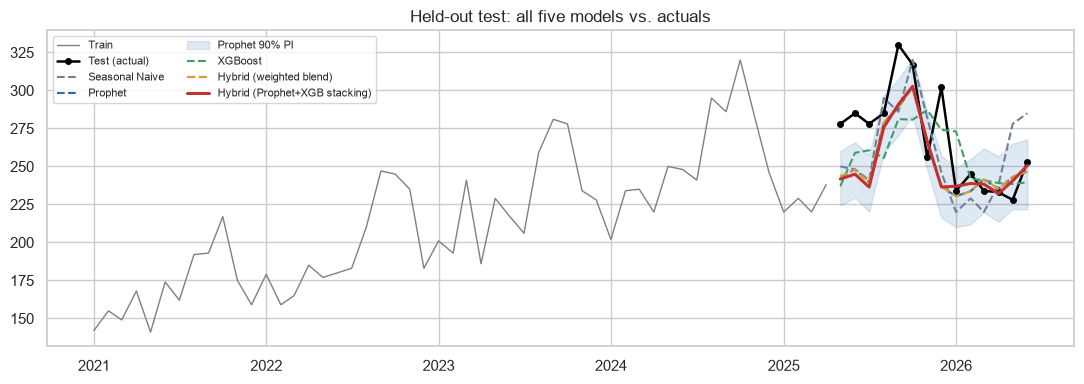

In [34]:
# Prediction-interval coverage check using Prophet's native 90% interval (replaces
# the residual-std approximation used when Prophet was simulated).
covered = np.mean((test["y"].values >= stat_lower) & (test["y"].values <= stat_upper))
print(f"Prophet's 90% prediction interval empirical coverage on test: {covered*100:.0f}% "
      f"({'well-calibrated' if 0.75 <= covered <= 1.0 else 'miscalibrated'} for a "
      f"{TEST_HORIZON}-point test set)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_full["period"], train_full["y"], color="gray", lw=1, label="Train")
ax.plot(test["period"], test["y"], color="black", lw=1.8, marker="o", ms=4, label="Test (actual)")
ax.plot(test["period"], naive_test_preds, "--", color="#718096", label="Seasonal Naive")
ax.plot(test["period"], stat_test_preds, "--", color="#2b6cb0", label="Prophet")
ax.fill_between(test["period"], stat_lower, stat_upper, color="#2b6cb0", alpha=0.15, label="Prophet 90% PI")
ax.plot(test["period"], gbt_test_preds, "--", color="#38a169", label="XGBoost")
ax.plot(test["period"], blend_test_preds, "--", color="#d69e2e", lw=1.6, label="Hybrid (weighted blend)")
ax.plot(test["period"], stack_test_preds, "-", color="#c53030", lw=2.2, label="Hybrid (Prophet+XGB stacking)")
ax.set_title("Held-out test: all five models vs. actuals")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.savefig("figs/06_test_fit.png"); plt.show()

## 12. Walk-forward CV — re-deriving the ensemble weight *per fold*

Each fold carves its own internal-validation slice from *that fold's* training
data, re-optimizes the blend weight on it, refits the stacked hybrid's residual
model on that fold's data, and only then scores the fold's held-out window. The
per-fold model **hyperparameters** are reused from the Section 8/9 searches (a
fresh `RandomizedSearchCV` per fold, per model, would be prohibitively slow) — but
every weight, every fit, and every residual model is fold-specific.

In [35]:
def walk_forward_cv(df: pd.DataFrame, n_folds=5, fold_horizon=None, val_frac=INTERNAL_VAL_FRACTION):
    n = len(df)
    fold_horizon = fold_horizon or max(6, TEST_HORIZON // 2)
    rows = []
    starts = np.unique(np.linspace(int(n * 0.40), n - fold_horizon, n_folds).astype(int))
    for start in starts:
        tr = df.iloc[:start].reset_index(drop=True)
        te = df.iloc[start:start + fold_horizon].reset_index(drop=True)
        if len(te) < 3 or len(tr) < SEASONAL_PERIOD * 2:
            continue
        n_v = max(6, int(len(tr) * val_frac))
        tr_fit, tr_val = tr.iloc[:-n_v].reset_index(drop=True), tr.iloc[-n_v:].reset_index(drop=True)

        pm = fit_prophet(tr_fit, best_prophet_cfg[0], best_prophet_cfg[1])
        pv = predict_prophet(pm, tr_val["period"])["yhat"].values
        Xf, yf = make_supervised(tr_fit)
        if len(Xf) < 6:
            continue
        xm = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                               random_state=RANDOM_SEED, n_jobs=-1, **xgb_search.best_params_)
        xm.fit(Xf, yf)
        xv = xgb_recursive_forecast(xm, tr_fit, len(tr_val))

        o = minimize_scalar(weighted_rmse, bounds=(0, 1), method="bounded",
                             args=(pv, xv, tr_val["y"].values))
        w = float(np.clip(o.x, 0, 1))

        pm_full = fit_prophet(tr, best_prophet_cfg[0], best_prophet_cfg[1])
        pt = predict_prophet(pm_full, te["period"])["yhat"].values
        Xff, yff = make_supervised(tr)
        xm_full = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                                    random_state=RANDOM_SEED, n_jobs=-1, **xgb_search.best_params_)
        xm_full.fit(Xff, yff)
        xt = xgb_recursive_forecast(xm_full, tr, len(te))

        blend_pred = w * pt + (1 - w) * xt
        blend_rmse = np.sqrt(mean_squared_error(te["y"], blend_pred))

        fitted_full = predict_prophet(pm_full, tr["period"])["yhat"].values
        r_lookup = pd.Series(tr["y"].values - fitted_full, index=tr["period"])
        feat_f = build_features(tr).dropna().reset_index(drop=True)
        feat_f["resid_target"] = r_lookup.reindex(feat_f["period"]).values
        Xr, yr = feat_f[FEATURE_COLS], feat_f["resid_target"]
        rm = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                               random_state=RANDOM_SEED, n_jobs=-1, **resid_search.best_params_)
        rm.fit(Xr, yr)
        stack_pred = stack_recursive_forecast(pm_full, rm, tr, len(te))
        stack_rmse = np.sqrt(mean_squared_error(te["y"], stack_pred))

        rows.append({"fold_end": tr["period"].iloc[-1].date(), "weight": round(w, 3),
                      "blend_rmse": round(float(blend_rmse), 2), "stack_rmse": round(float(stack_rmse), 2)})
    return pd.DataFrame(rows)

cv_df = walk_forward_cv(train_full, n_folds=5)
print(cv_df.to_string(index=False))
print(f"\nWeighted-blend RMSE across folds: mean={cv_df['blend_rmse'].mean():.1f}, std={cv_df['blend_rmse'].std():.1f}")
print(f"Stacked-hybrid RMSE across folds:  mean={cv_df['stack_rmse'].mean():.1f}, std={cv_df['stack_rmse'].std():.1f}")

16:02:53 - cmdstanpy - INFO - Chain [1] start processing
16:03:04 - cmdstanpy - INFO - Chain [1] done processing
16:03:04 - cmdstanpy - INFO - Chain [1] start processing
16:03:05 - cmdstanpy - INFO - Chain [1] done processing
16:03:06 - cmdstanpy - INFO - Chain [1] start processing
16:03:07 - cmdstanpy - INFO - Chain [1] done processing
16:03:07 - cmdstanpy - INFO - Chain [1] start processing
16:03:08 - cmdstanpy - INFO - Chain [1] done processing
16:03:09 - cmdstanpy - INFO - Chain [1] start processing
16:03:10 - cmdstanpy - INFO - Chain [1] done processing
16:03:10 - cmdstanpy - INFO - Chain [1] start processing
16:03:11 - cmdstanpy - INFO - Chain [1] done processing
16:03:12 - cmdstanpy - INFO - Chain [1] start processing
16:03:13 - cmdstanpy - INFO - Chain [1] done processing
16:03:13 - cmdstanpy - INFO - Chain [1] start processing
16:03:14 - cmdstanpy - INFO - Chain [1] done processing


  fold_end  weight  blend_rmse  stack_rmse
2023-02-01   1.000       24.45       24.43
2023-08-01   0.605       17.01       16.13
2024-02-01   1.000       12.69       13.61
2024-09-01   0.844       24.23       25.93

Weighted-blend RMSE across folds: mean=19.6, std=5.8
Stacked-hybrid RMSE across folds:  mean=20.0, std=6.1


## 13. Anchor-point sensitivity — does the excluded July-2026 point matter?

Section 2 excluded the provisional last month from training/testing. Here we
quantify what happens to a forward forecast if that decision were reversed, using
the stacked hybrid (the model recommended in Section 14).

In [36]:
horizon_check = 3
anchored_on_confirmed = stack_recursive_forecast(prophet_model, resid_model, train_full, horizon_check)

full_with_provisional = pd.concat([train_full, provisional_row], ignore_index=True)
prophet_model_prov = fit_prophet(full_with_provisional, best_prophet_cfg[0], best_prophet_cfg[1])
fitted_prov = predict_prophet(prophet_model_prov, full_with_provisional["period"])["yhat"].values
r_lookup_prov = pd.Series(full_with_provisional["y"].values - fitted_prov, index=full_with_provisional["period"])
feat_prov = build_features(full_with_provisional).dropna().reset_index(drop=True)
feat_prov["resid_target"] = r_lookup_prov.reindex(feat_prov["period"]).values
resid_model_prov = xgb.XGBRegressor(objective="reg:squarederror", tree_method="hist",
                                     random_state=RANDOM_SEED, n_jobs=-1, **resid_search.best_params_)
resid_model_prov.fit(feat_prov[FEATURE_COLS], feat_prov["resid_target"])
anchored_on_provisional = stack_recursive_forecast(prophet_model_prov, resid_model_prov,
                                                     full_with_provisional, horizon_check)

sens = pd.DataFrame({
    "step_ahead": np.arange(1, horizon_check + 1),
    "anchored_on_last_confirmed_month": anchored_on_confirmed.round(1),
    "anchored_on_provisional_month": anchored_on_provisional.round(1),
    "pct_diff": (100 * (anchored_on_provisional / anchored_on_confirmed - 1)).round(1),
})
print(sens.to_string(index=False))
print(f"\nUsing the unverified last month as the anchor shifts the near-term forecast "
      f"by up to {sens['pct_diff'].abs().max():.0f}% — material enough that this should "
      f"be resolved against the data source, not assumed, before any forecast ships.")

16:03:15 - cmdstanpy - INFO - Chain [1] start processing
16:03:16 - cmdstanpy - INFO - Chain [1] done processing


 step_ahead  anchored_on_last_confirmed_month  anchored_on_provisional_month  pct_diff
          1                             241.7                          193.3     -20.0
          2                             244.9                          214.3     -12.5
          3                             236.4                          216.9      -8.3

Using the unverified last month as the anchor shifts the near-term forecast by up to 20% — material enough that this should be resolved against the data source, not assumed, before any forecast ships.


## 14. Model comparison & honest verdict

In [37]:
display_df = results_df.copy()
display_df.index.name = "Model"
print(display_df.round(2).to_string())

print(f"\n{'='*82}")
print("HEADLINE FINDING:")
print(f"  Best test RMSE belongs to: '{winner}'.")
print(f"  {n_beat_naive} of 4 modeled approaches beat seasonal-naive on held-out RMSE.")
print(f"{'='*82}")

naive_rmse = display_df.loc["Seasonal Naive", "RMSE"]
best_rmse_val = display_df["RMSE"].min()
improvement = 100 * (1 - best_rmse_val / naive_rmse)
print(f"\nBest model improves on seasonal-naive by {improvement:.1f}% RMSE "
      f"({best_rmse_val:.1f} vs {naive_rmse:.1f}).")
print(f"Walk-forward CV: weighted-blend mean RMSE={cv_df['blend_rmse'].mean():.1f} "
      f"(std={cv_df['blend_rmse'].std():.1f}); stacked-hybrid mean RMSE={cv_df['stack_rmse'].mean():.1f} "
      f"(std={cv_df['stack_rmse'].std():.1f}) across {len(cv_df)} folds.")

                                 MAE   RMSE  MAPE%    R2  MASE
Model                                                         
Hybrid — weighted blend        21.04  27.85   7.42  0.24  0.76
Prophet                        21.04  27.85   7.42  0.24  0.76
XGBoost                        24.09  27.89   8.69  0.23  0.87
Hybrid — Prophet+XGB stacking  20.42  28.16   7.14  0.22  0.74
Seasonal Naive                 26.57  31.14   9.86  0.04  0.96

HEADLINE FINDING:
  Best test RMSE belongs to: 'Hybrid — weighted blend'.
  4 of 4 modeled approaches beat seasonal-naive on held-out RMSE.

Best model improves on seasonal-naive by 10.6% RMSE (27.9 vs 31.1).
Walk-forward CV: weighted-blend mean RMSE=19.6 (std=5.8); stacked-hybrid mean RMSE=20.0 (std=6.1) across 4 folds.


## 15. Reproducibility

In [38]:
import sklearn, scipy
print(f"random_seed = {RANDOM_SEED}")
print(f"numpy={np.__version__}  pandas={pd.__version__}  scikit-learn={sklearn.__version__}  "
      f"scipy={scipy.__version__}")
print(f"xgboost={xgb.__version__}  prophet={__import__('prophet').__version__}")

random_seed = 42
numpy=2.5.1  pandas=3.0.3  scikit-learn=1.9.0  scipy=1.18.0
xgboost=3.3.0  prophet=1.3.0
